# **ITAL 1371 Mid-Term Project **

# **Ved Dalwadi Data Cleaning and Train Test spliting**

In [1]:
#Importing all necessary tools for the dataset cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
#Styling for graph
plt.style.use('classic')
sns.set_palette("Blues")
#Import dataset from url which I put in github Url
df = pd.read_csv('https://raw.githubusercontent.com/VedD376/ITAI-1371-ML-Dataset/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())
df.info()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [2]:
#This shows Total charges as an object. This is not ideal, as when the machine cannot learn from strings
print(df['TotalCharges'].dtype)
#We first have to fill the blank rows
blank_Rows = df[df['TotalCharges'].str.strip() == '']
print("Number of blank rows in Total Charges:", len(blank_Rows))
#This will convert into numbers and if left blank it will become NAN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors ='coerce')
#Confrim the blank rows
print(df['TotalCharges'].isnull().sum())
#Fills any missing rows with 0 as the customers with no value haven't been billed yet.
df['TotalCharges'] = df['TotalCharges'].fillna(0)
#Confrim no more missing data
print(df['TotalCharges'].isnull().sum())

object
Number of blank rows in Total Charges: 11
11
0


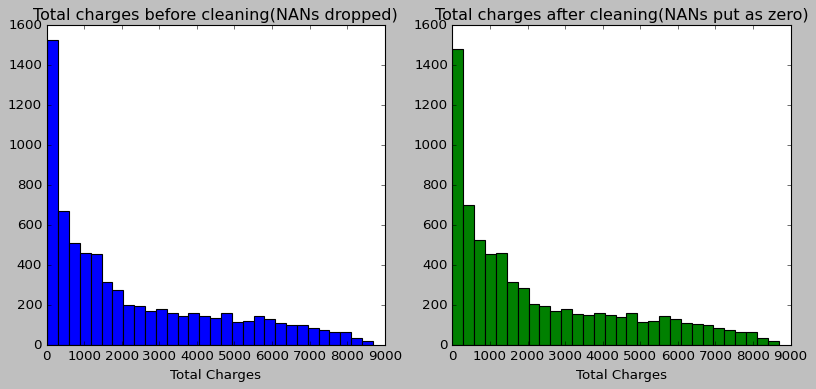

In [3]:
#Putting the raw dataset to show before and after matlib
df_raw = pd.read_csv('https://raw.githubusercontent.com/VedD376/ITAI-1371-ML-Dataset/main/WA_Fn-UseC_-Telco-Customer-Churn.csv')
#creates 2 plots for the before and after
fig, axes = plt.subplots(1, 2, figsize=(12,5))
before_Filling = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
#This plots the raw dataset as a histogram first
axes[0].hist(before_Filling.dropna(), bins=30, color='blue')
axes[0].set_title('Total charges before cleaning(NANs dropped)')
axes[0].set_xlabel('Total Charges')
#This first graph shows a high number of customers with a low amount billed
#This plots the raw dataset as a histogram first
axes[1].hist(df['TotalCharges'], bins=30, color='green')
axes[1].set_title('Total charges after cleaning(NANs put as zero)')
axes[1].set_xlabel('Total Charges')
plt.show()
#The before and after histograms are very similar because the number of rows changed was 11 out of 7000, which won't do much; however, this step is still important to make the machine more accurate,
#you need to do the small things that even though they may not make a huge visaul differnce it can still increase the accuarcy of the AI by some amount.
#which if this did not happen could cause problems later on in the process if this simple turing them into zeros did not occour.

In [4]:
#We now want to drop the customer ID as this increasing number can cause the machine to focus it's attentition on the last customer more than the first when both thier data is equally as imporant
df = df.drop('customerID', axis = 1)
df.columns
#Code done by Ved Dalwadi

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
#Now we want to split the data into testing and trianing sets so the AI can learn and make sure it's not just memorizing the anwsers.
train_df, test_df = train_test_split(df, test_size=0.30, random_state=42)
#We will print each one to confrim that 70% goes to train and 30% goes to test
print("Training state:", train_df.shape)
print("test state:", test_df.shape)

Training state: (4930, 20)
test state: (2113, 20)


In [6]:
#Now we want to print the before and after of the dataset cleaning
print("Before cleaning (Raw)")
print(df_raw[['customerID', 'tenure', 'TotalCharges']].head(10))
print("After cleaning (Clean)")
print(df[[ 'tenure', 'TotalCharges']].head(10))

Before cleaning (Raw)
   customerID  tenure TotalCharges
0  7590-VHVEG       1        29.85
1  5575-GNVDE      34       1889.5
2  3668-QPYBK       2       108.15
3  7795-CFOCW      45      1840.75
4  9237-HQITU       2       151.65
5  9305-CDSKC       8        820.5
6  1452-KIOVK      22       1949.4
7  6713-OKOMC      10        301.9
8  7892-POOKP      28      3046.05
9  6388-TABGU      62      3487.95
After cleaning (Clean)
   tenure  TotalCharges
0       1         29.85
1      34       1889.50
2       2        108.15
3      45       1840.75
4       2        151.65
5       8        820.50
6      22       1949.40
7      10        301.90
8      28       3046.05
9      62       3487.95


# **Monepha Mitchell EDA and Feature Engineering**

In [7]:
# Th is to confirm that I am working only with the 70% training dataset
print("Training set shape:", train_df.shape)

# Display a sample of the training data
train_df.head()

Training set shape: (4930, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1695,Male,0,Yes,Yes,54,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Electronic check,70.70,3770.00,No
1095,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.55,80.55,No
3889,Male,0,No,No,13,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.30,259.65,No
3667,Female,1,Yes,Yes,24,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,Yes,Electronic check,96.55,2263.45,No
2902,Female,1,No,No,6,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.10,450.90,No


In [8]:
# Display the column names and data types
train_df.info()

# Check for missing values in the training set
print("\nMissing values in each column:")
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 4930 entries, 1695 to 860
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4930 non-null   object 
 1   SeniorCitizen     4930 non-null   int64  
 2   Partner           4930 non-null   object 
 3   Dependents        4930 non-null   object 
 4   tenure            4930 non-null   int64  
 5   PhoneService      4930 non-null   object 
 6   MultipleLines     4930 non-null   object 
 7   InternetService   4930 non-null   object 
 8   OnlineSecurity    4930 non-null   object 
 9   OnlineBackup      4930 non-null   object 
 10  DeviceProtection  4930 non-null   object 
 11  TechSupport       4930 non-null   object 
 12  StreamingTV       4930 non-null   object 
 13  StreamingMovies   4930 non-null   object 
 14  Contract          4930 non-null   object 
 15  PaperlessBilling  4930 non-null   object 
 16  PaymentMethod     4930 non-null   object 
 17

In [9]:
# Summary statistics for the numerical features assigned to my section
print("Summary statistics for tenure and MonthlyCharges:")
display(train_df[['tenure', 'MonthlyCharges']].describe())

# Frequency counts for the categorical features
print("\nContract type counts:")
display(train_df['Contract'].value_counts())

print("\nPayment method counts:")
display(train_df['PaymentMethod'].value_counts())

Summary statistics for tenure and MonthlyCharges:


,tenure,MonthlyCharges
count,4930.000000,4930.000000
mean,32.434280,64.795122
std,24.479003,30.141247
min,0.000000,18.250000
25%,9.000000,35.400000
50%,29.000000,70.400000
75%,55.000000,89.850000
max,72.000000,118.600000



Contract type counts:


,count
Contract,
Month-to-month,2690
Two year,1186
One year,1054



Payment method counts:


,count
PaymentMethod,
Electronic check,1666
Mailed check,1113
Bank transfer (automatic),1086
Credit card (automatic),1065


### Summary Statistics Analysis

The summary statistics provide an overview of customer tenure and monthly charges in the training data. The frequency tables also show which contract types and payment methods are most common. These features may be related to customer churn because contract commitment, length of service, and monthly cost can influence whether a customer remains with the company.

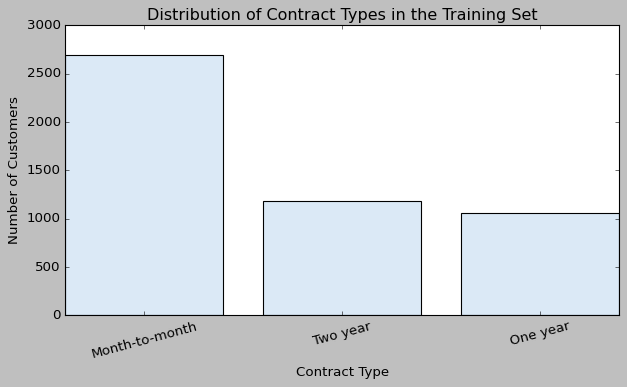

In [10]:
import matplotlib.pyplot as plt

# Display the distribution of customer contract types
contract_counts = train_df['Contract'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(contract_counts.index, contract_counts.values)
plt.title('Distribution of Contract Types in the Training Set')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Contract Type Analysis

The chart shows how customers are distributed across month-to-month, one-year, and two-year contracts. Month-to-month customers may have more flexibility to leave the company, while customers with longer contracts may be less likely to churn.

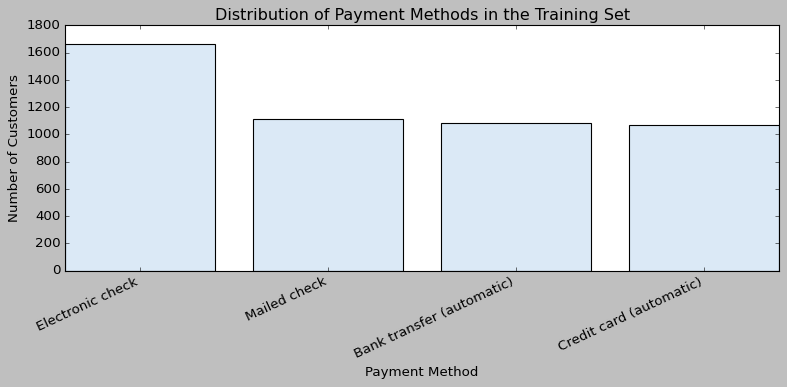

In [11]:
# Display the distribution of customer payment methods
payment_counts = train_df['PaymentMethod'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(payment_counts.index, payment_counts.values)
plt.title('Distribution of Payment Methods in the Training Set')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### Payment Method Analysis

This chart shows the payment methods used by customers in the training set. Reviewing payment methods may help identify whether customers using certain payment options are more likely to churn than others.

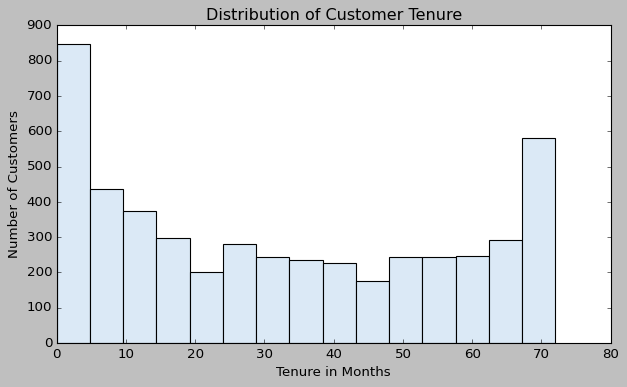

In [12]:
# Display the distribution of customer tenure
plt.figure(figsize=(8, 5))
plt.hist(train_df['tenure'], bins=15, edgecolor='black')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure in Months')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


### Tenure Analysis

The histogram shows how long customers have remained with the company. Customers with shorter tenure may still be deciding whether the service meets their needs, while customers with longer tenure may have developed greater loyalty to the company.

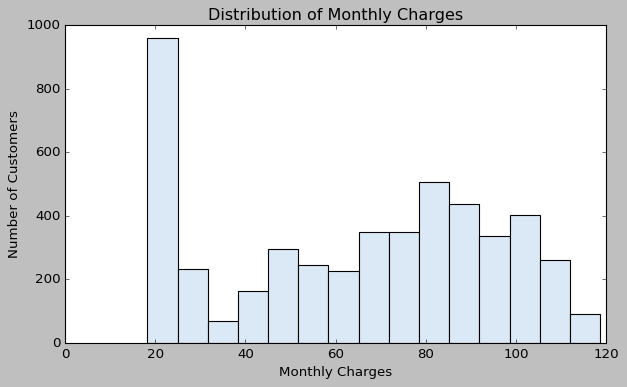

In [13]:
# Display the distribution of monthly customer charges
plt.figure(figsize=(8, 5))
plt.hist(train_df['MonthlyCharges'], bins=15, edgecolor='black')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Monthly Charges Analysis

The histogram shows the range of monthly charges paid by customers. Higher monthly costs may affect customer satisfaction and could be associated with a greater likelihood of churn.

Churn counts:
Churn
No     3635
Yes    1295
Name: count, dtype: int64

Churn percentages:
Churn
No     73.73
Yes    26.27
Name: proportion, dtype: float64


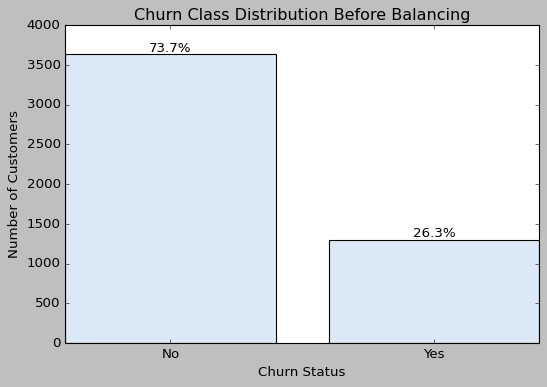

In [14]:
# Count the number and percentage of customers in each churn class
churn_counts = train_df['Churn'].value_counts()
churn_percentages = train_df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percentages.round(2))

# Plot the class distribution
plt.figure(figsize=(7, 5))
bars = plt.bar(churn_counts.index, churn_counts.values)

plt.title('Churn Class Distribution Before Balancing')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

# Add percentages above each bar
for bar, label in zip(bars, churn_counts.index):
    percentage = churn_percentages[label]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{percentage:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

### Churn Class Distribution

The training data contains more customers who did not churn than customers who did churn. This class imbalance could cause a machine learning model to favor the majority class. A class-balancing method will be applied after the categorical data has been converted into numerical values.

In [15]:
# Create a copy so the original training set remains available
train_engineered = train_df.copy()

In [16]:
# Group customer tenure into meaningful categories
tenure_bins = [-1, 12, 24, 48, 72]
tenure_labels = [
    'New Customer',
    'Developing Customer',
    'Established Customer',
    'Long-Term Customer'
]

train_engineered['TenureGroup'] = pd.cut(
    train_engineered['tenure'],
    bins=tenure_bins,
    labels=tenure_labels
)

# Display a sample of the new feature
display(train_engineered[['tenure', 'TenureGroup']].head(10))

# Show the number of customers in each tenure group
print(train_engineered['TenureGroup'].value_counts().sort_index())

,tenure,TenureGroup
1695,54,Long-Term Customer
1095,1,New Customer
3889,13,Developing Customer
3667,24,Developing Customer
2902,6,New Customer
1630,38,Established Customer
4294,12,New Customer
1881,26,Established Customer
4710,6,New Customer
1612,67,Long-Term Customer


TenureGroup
New Customer            1529
Developing Customer      695
Established Customer    1143
Long-Term Customer      1563
Name: count, dtype: int64


### Tenure Group Feature

I created a TenureGroup feature to place customers into meaningful categories based on how long they have stayed with the company. This may help a machine learning model identify differences between newer customers and long-term customers more clearly than using the number of months alone.

In [17]:
# Service columns that indicate whether a customer subscribes to each service
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Count each service marked "Yes"
train_engineered['NumberOfServices'] = (
    train_engineered[service_columns]
    .eq('Yes')
    .sum(axis=1)
)

# Display a sample of the new feature
display(
    train_engineered[
        service_columns + ['NumberOfServices']
    ].head(10)
)

print("\nNumber of services summary:")
print(train_engineered['NumberOfServices'].describe())

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,NumberOfServices
1695,Yes,Yes,No,Yes,No,Yes,Yes,No,5
1095,Yes,No,No,No,No,No,Yes,No,2
3889,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,1
3667,Yes,No,No,No,Yes,No,Yes,Yes,4
2902,Yes,No,Yes,No,No,No,No,No,2
1630,Yes,Yes,No,Yes,Yes,No,Yes,Yes,6
4294,Yes,No,Yes,No,No,No,Yes,No,3
1881,No,No phone service,Yes,Yes,No,No,No,Yes,3
4710,No,No phone service,No,Yes,Yes,Yes,No,No,3
1612,Yes,Yes,No,Yes,Yes,No,No,No,4



Number of services summary:
count    4930.000000
mean        3.374848
std         2.072890
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: NumberOfServices, dtype: float64


### Number of Services Feature

I created a NumberOfServices feature by counting how many services each customer uses. This combines information from several related columns into one useful measurement. Customers who subscribe to more services may be more connected to the company and potentially less likely to leave.

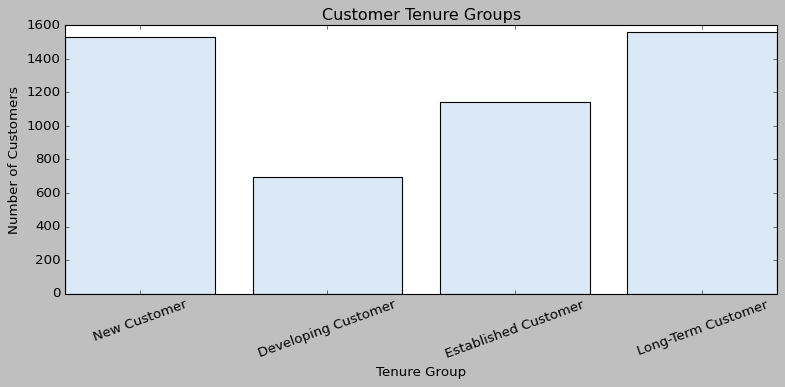

In [18]:
# Visualize the new tenure groups
tenure_group_counts = (
    train_engineered['TenureGroup']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.bar(
    tenure_group_counts.index.astype(str),
    tenure_group_counts.values
)
plt.title('Customer Tenure Groups')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

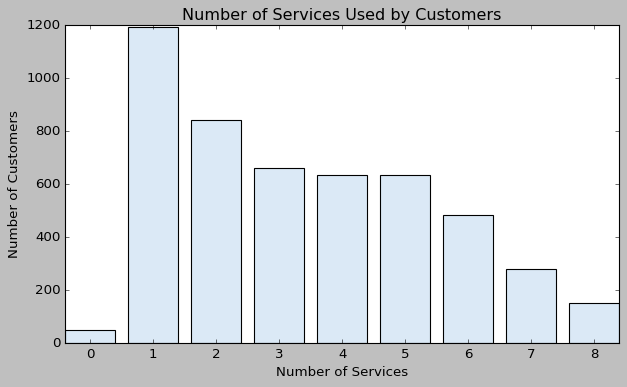

In [19]:
# Visualize the number of services used by customers
service_count_distribution = (
    train_engineered['NumberOfServices']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(
    service_count_distribution.index.astype(str),
    service_count_distribution.values
)
plt.title('Number of Services Used by Customers')
plt.xlabel('Number of Services')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [20]:
# Compare selected columns before and after feature engineering
print("Sample before feature engineering:")
display(train_df[['tenure', 'Churn']].head())

print("\nSample after feature engineering:")
display(
    train_engineered[
        ['tenure', 'TenureGroup', 'NumberOfServices', 'Churn']
    ].head()
)

Sample before feature engineering:


,tenure,Churn
1695,54,No
1095,1,No
3889,13,No
3667,24,No
2902,6,No



Sample after feature engineering:


,tenure,TenureGroup,NumberOfServices,Churn
1695,54,Long-Term Customer,5,No
1095,1,New Customer,2,No
3889,13,Developing Customer,1,No
3667,24,Developing Customer,4,No
2902,6,New Customer,2,No


Class balancing is completed after the one-hot encoding section because SMOTE requires numerical features.

# **Nigel Bontiff - Encoding, Scaling, and Distribution Comparison**

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Preprocessing for the training data
train_person3 = train_df.copy()

print("Training data shape before Person 3 preprocessing:")
print(train_person3.shape)

print("\nFirst five rows before Person 3 preprocessing:")
print(train_person3.head())

Training data shape before Person 3 preprocessing:
(4930, 20)

First five rows before Person 3 preprocessing:
      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
1695    Male              0     Yes        Yes      54          Yes   
1095    Male              0      No         No       1          Yes   
3889    Male              0      No         No      13          Yes   
3667  Female              1     Yes        Yes      24          Yes   
2902  Female              1      No         No       6          Yes   

     MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
1695           Yes             DSL                   No                  Yes   
1095            No     Fiber optic                   No                   No   
3889            No              No  No internet service  No internet service   
3667            No     Fiber optic                   No                   No   
2902            No     Fiber optic                  Yes        

In [22]:
object_columns = train_person3.select_dtypes(include=['object']).columns

for column in object_columns:
    train_person3[column] = train_person3[column].astype(str).str.strip()

service_columns = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for column in service_columns:
    if column in train_person3.columns:
        train_person3[column] = train_person3[column].replace({
            'No internet service': 'No',
            'No phone service': 'No'
        })

print("Unique values after simplifying service-related columns:\n")

for column in service_columns:
    if column in train_person3.columns:
        print(column, ":", train_person3[column].unique())

Unique values after simplifying service-related columns:

MultipleLines : ['Yes' 'No']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['Yes' 'No']
StreamingTV : ['Yes' 'No']
StreamingMovies : ['No' 'Yes']


In [23]:
# Pull out the target (Churn) BEFORE dropping it, so we still have the column to read
y_train_person3 = train_person3['Churn']

# Convert Churn from Yes/No into 1/0
# Yes = customer churned
# No = customer did not churn

y_train_person3 = y_train_person3.map({
    'No': 0,
    'Yes': 1
})

# Now drop Churn to build the feature set (X) used for encoding/scaling
X_train_person3 = train_person3.drop(columns=['Churn'])

print("Target value counts after converting Churn to 0 and 1:")
print(y_train_person3.value_counts())

print("\nTarget percentage distribution:")
print((y_train_person3.value_counts(normalize=True) * 100).round(2))

Target value counts after converting Churn to 0 and 1:
Churn
0    3635
1    1295
Name: count, dtype: int64

Target percentage distribution:
Churn
0    73.73
1    26.27
Name: proportion, dtype: float64


In [24]:
# Find remaining categorical columns that still contain text
categorical_columns = X_train_person3.select_dtypes(include=['object']).columns

print("Categorical columns before one-hot encoding:")
print(list(categorical_columns))

# One-hot encode categorical columns
X_train_encoded = pd.get_dummies(
    X_train_person3,
    columns=categorical_columns,
    drop_first=True
)

# This section will convert True/False columns into 1/0 integers
bool_columns = X_train_encoded.select_dtypes(include=['bool']).columns
X_train_encoded[bool_columns] = X_train_encoded[bool_columns].astype(int)

print("\nTraining data shape after one-hot encoding:")
print(X_train_encoded.shape)

print("\nFirst five rows after one-hot encoding:")
print(X_train_encoded.head())

Categorical columns before one-hot encoding:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training data shape after one-hot encoding:
(4930, 23)

First five rows after one-hot encoding:
      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
1695              0      54           70.70       3770.00            1   
1095              0       1           80.55         80.55            1   
3889              0      13           19.30        259.65            1   
3667              1      24           96.55       2263.45            0   
2902              1       6           74.10        450.90            0   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
1695            1               1                 1                  1   
1095            0        

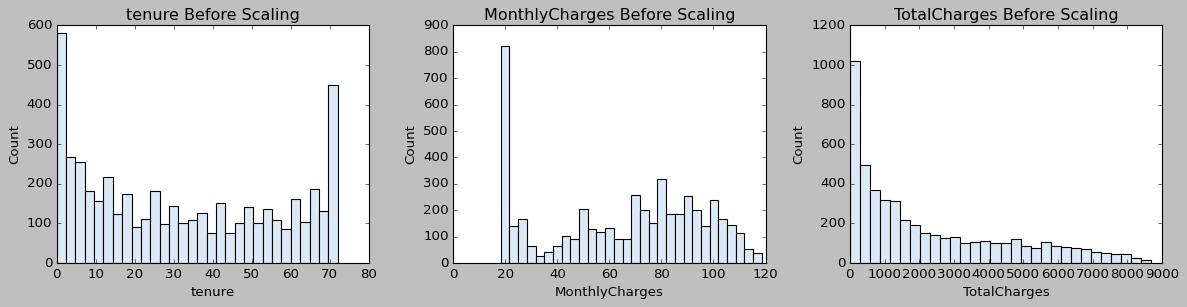

In [25]:
# The numeric columns I'm scaling
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Show distributions before scaling.
plt.figure(figsize=(15, 4))

for i, column in enumerate(columns_to_scale):
    plt.subplot(1, 3, i + 1)
    plt.hist(X_train_encoded[column], bins=30)
    plt.title(f'{column} Before Scaling')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [26]:
# StandardScaler to put numeric columns on a similar scale
scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(
    X_train_scaled[columns_to_scale]
)

print("First five rows after scaling tenure, MonthlyCharges, and TotalCharges:")
print(X_train_scaled[columns_to_scale].head())

print("\nSummary statistics after scaling:")
print(X_train_scaled[columns_to_scale].describe())

First five rows after scaling tenure, MonthlyCharges, and TotalCharges:
        tenure  MonthlyCharges  TotalCharges
1695  0.881078        0.195927      0.654503
1095 -1.284263        0.522755     -0.974042
3889 -0.793997       -1.509551     -0.894986
3667 -0.344587        1.053643     -0.010497
2902 -1.079985        0.308740     -0.810567

Summary statistics after scaling:
             tenure  MonthlyCharges  TotalCharges
count  4.930000e+03    4.930000e+03  4.930000e+03
mean  -8.359326e-17    1.441263e-16 -8.071074e-17
std    1.000101e+00    1.000101e+00  1.000101e+00
min   -1.325118e+00   -1.544390e+00 -1.009597e+00
25%   -9.574188e-01   -9.753446e-01 -8.328141e-01
50%   -1.403092e-01    1.859726e-01 -3.904480e-01
75%    9.219333e-01    8.313332e-01  6.722259e-01
max    1.616477e+00    1.785272e+00  2.823926e+00


### Monepha class balancing with SMOTE

In [27]:


from imblearn.over_sampling import SMOTE

# Display the churn distribution before balancing
print("Class distribution before SMOTE:")
print(y_train_person3.value_counts())

print("\nClass percentages before SMOTE:")
print((y_train_person3.value_counts(normalize=True) * 100).round(2))

# Apply SMOTE only to the encoded and scaled training data
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train_person3
)

# Display the churn distribution after balancing
print("\nClass distribution after SMOTE:")
print(y_train_balanced.value_counts())

print("\nClass percentages after SMOTE:")
print((y_train_balanced.value_counts(normalize=True) * 100).round(2))

print("\nBalanced training data shape:")
print(X_train_balanced.shape)

Class distribution before SMOTE:
Churn
0    3635
1    1295
Name: count, dtype: int64

Class percentages before SMOTE:
Churn
0    73.73
1    26.27
Name: proportion, dtype: float64

Class distribution after SMOTE:
Churn
0    3635
1    3635
Name: count, dtype: int64

Class percentages after SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64

Balanced training data shape:
(7270, 23)


### Monepha continued

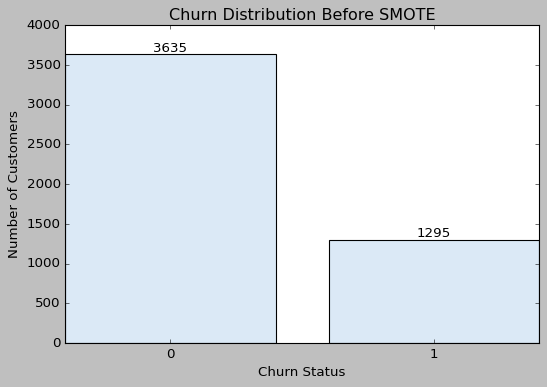

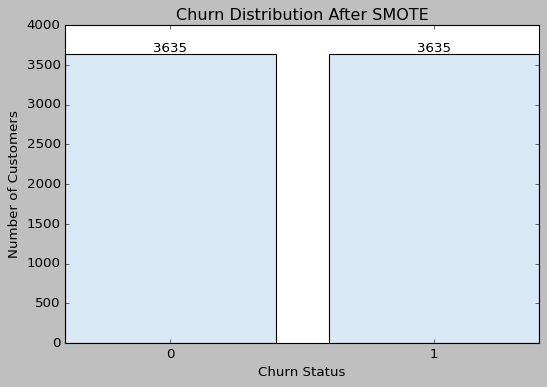

In [28]:


# Create class counts before and after SMOTE
before_counts = y_train_person3.value_counts().sort_index()
after_counts = y_train_balanced.value_counts().sort_index()

# Plot the class distribution before balancing
plt.figure(figsize=(7, 5))
bars_before = plt.bar(
    before_counts.index.astype(str),
    before_counts.values
)

plt.title('Churn Distribution Before SMOTE')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

for bar in bars_before:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# Plot the class distribution after balancing
plt.figure(figsize=(7, 5))
bars_after = plt.bar(
    after_counts.index.astype(str),
    after_counts.values
)

plt.title('Churn Distribution After SMOTE')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

for bar in bars_after:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

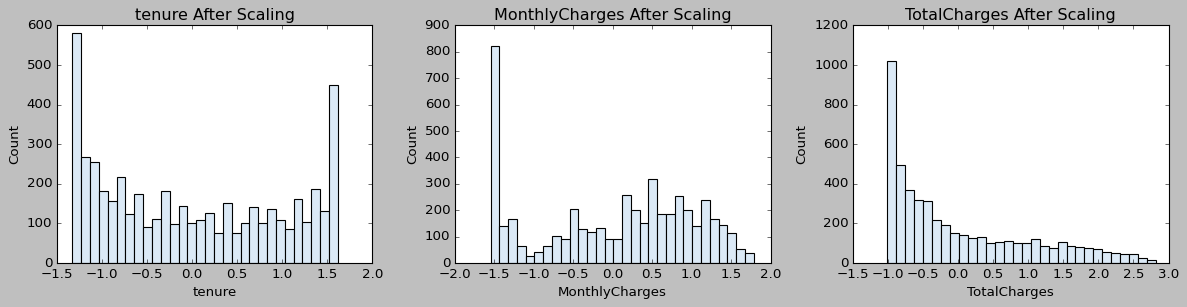

In [29]:
# display for distributions after scaling
plt.figure(figsize=(15, 4))

for i, column in enumerate(columns_to_scale):
    plt.subplot(1, 3, i + 1)
    plt.hist(X_train_scaled[column], bins=30)
    plt.title(f'{column} After Scaling')
    plt.xlabel(column)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [30]:
# I created a validation split from the training data so the original test_df stays untouched
# X is the fully encoded + scaled feature set, y is the target saved earlier (Churn is already
# separated out, so there's no 'Churn' column left in X to drop)

X = X_train_scaled
y = y_train_person3

X_train_model, X_val_model, y_train_model, y_val_model = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

log_reg_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_model, y_train_model)

y_pred = log_reg_model.predict(X_val_model)

print("Accuracy Score:")
print(accuracy_score(y_val_model, y_pred))

print("\nClassification Report:")
print(classification_report(y_val_model, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val_model, y_pred))

Accuracy Score:
0.7434077079107505

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81       727
           1       0.51      0.79      0.62       259

    accuracy                           0.74       986
   macro avg       0.71      0.76      0.71       986
weighted avg       0.80      0.74      0.76       986


Confusion Matrix:
[[528 199]
 [ 54 205]]


# **Discuss how you would use this dataset to solve a ML problem**
This preprocessing helps because the original Telco Churn dataset has a lot of text values that a machine learning model cannot use by itself. For example, columns like internet service, payment method, contract type, and other customer service features are written as words instead of numbers. By cleaning values like “No internet service” and “No phone service” into just “No,” the data becomes more consistent and easier to work with.

After that, one-hot encoding changes the categorical columns into 0 and 1 values, which makes the data usable for a machine learning model. I also scaled the numerical columns, including tenure, MonthlyCharges, and TotalCharges, because those columns are on different ranges. Scaling helps make sure one feature does not seem more important just because it has larger numbers.

I also used class_weight='balanced' in the Logistic Regression model because the dataset has more customers who did not churn than customers who did churn. This helps the model pay more attention to the smaller churn group instead of mainly predicting the majority class. Overall, these steps help turn the training data into a cleaner and more model-ready dataset that could be used to predict whether a customer is likely to churn.